# Project: ML model comparison on Breast Cancer dataset

## Setup

### Data

We use the Breast Cancer Dataset:

In [86]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

PLOT_CONFIG = {
    "figsize": (6, 4),
    "title_size": 14,
    "label_size": 11,
    "tick_size": 10,
    "legend_size": 10,
}

def aspect_square(ax):
    ax.set_aspect((ax.get_xlim()[1]-ax.get_xlim()[0])/(ax.get_ylim()[1]-ax.get_ylim()[0]))

In [50]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [51]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Exploratory Data Analysis

Let's visualize the dataset with some plots:

- Class distribution

- Feature distributions

- Correlation heatmap

- Feature vs Target (separation power)

- Boxplots (outlier detection)

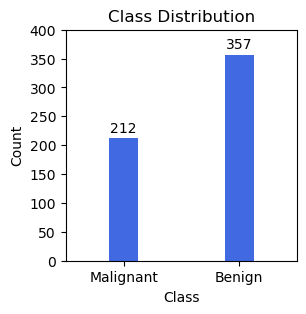

In [109]:
classes, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(3,3))
bars = plt.bar(classes, counts, width=0.25, color='royalblue')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.xticks([0, 1], ["Malignant", "Benign"])
plt.xlim([-0.5,1.5])
plt.ylim([0,400])
aspect_square(plt.gca())
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

The dataset is slightly imbalanced, with more benign than malignant samples.  
However, the imbalance is not severe, so standard evaluation metrics remain appropriate without requiring special handling.

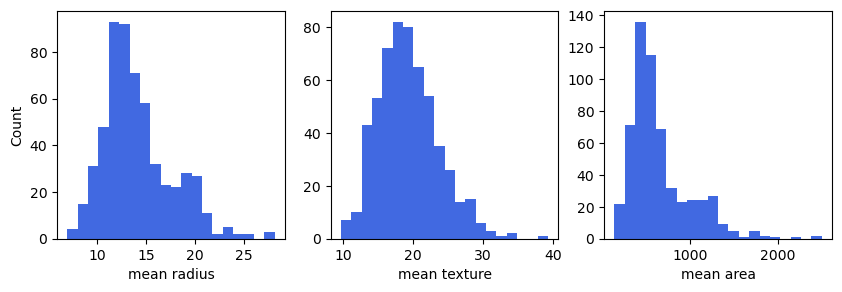

In [104]:
important_features = ["mean radius", "mean texture", "mean area"]

f, ax = plt.subplots(1,3,figsize=(10,3))
for i,feature in enumerate(important_features):
    ax[i].hist(X[feature], bins=20, color='royalblue')
    ax[i].set_xlabel(feature)
    aspect_square(ax[i])
    if i==0:
        ax[i].set_ylabel('Count')
plt.show()

The selected features show diverse distributions, with some skewness and long tails, particularly for mean area.  
This suggests that feature scaling may be beneficial for models sensitive to feature magnitude, such as logistic regression.

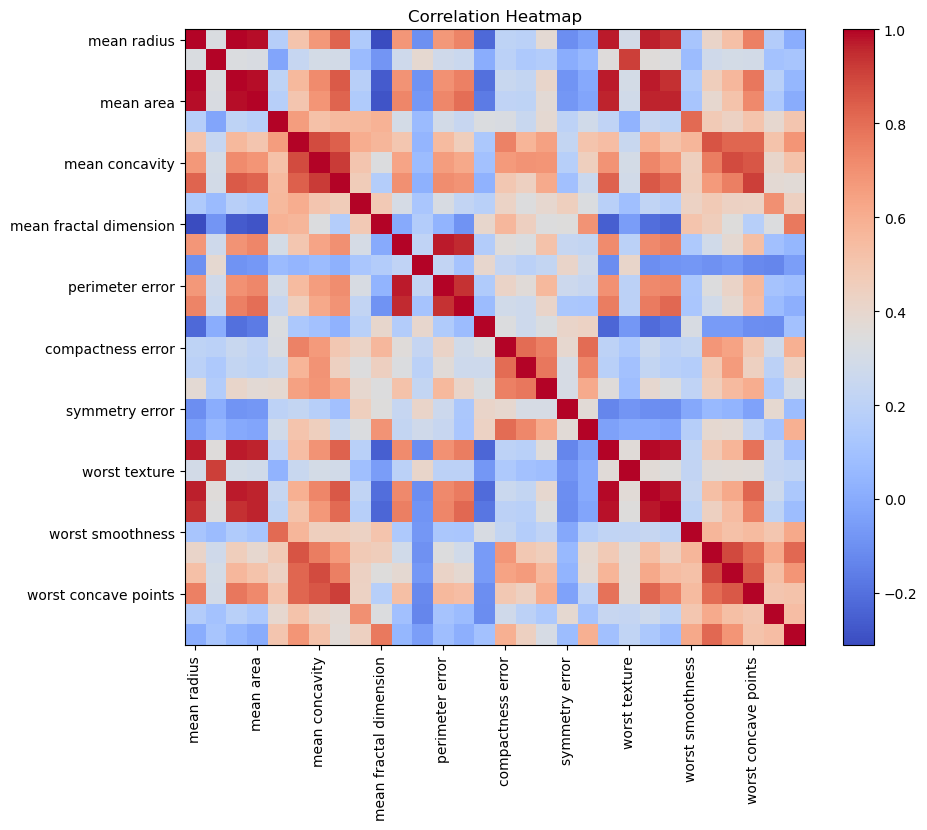

In [93]:
corr = X.corr()

plt.figure(figsize=(10, 8))

plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()

ticks = range(0, len(corr.columns), 3)
plt.xticks(ticks, corr.columns[ticks], rotation=90)
plt.yticks(ticks, corr.columns[ticks])

plt.title("Correlation Heatmap")
plt.show()

Several features are highly correlated, indicating redundancy in the dataset.  
This is expected, as many variables describe related physical properties of tumors.  
Tree-based models are less sensitive to this, while linear models may be affected by multicollinearity.

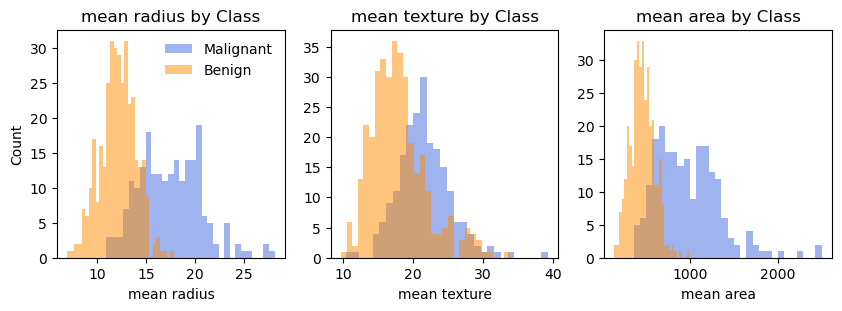

In [94]:
f, ax = plt.subplots(1,3,figsize=(10,3))

for i, feature in enumerate(important_features):
    ax[i].hist(X[y == 0][feature], bins=30, alpha=0.5, label="Malignant", color='royalblue')
    ax[i].hist(X[y == 1][feature], bins=30, alpha=0.5, label="Benign", color='darkorange')
    ax[i].set_title(f"{feature} by Class")
    ax[i].set_xlabel(feature)
    aspect_square(ax[i])
    if i==0:
        ax[i].legend(frameon=False)
        ax[i].set_ylabel("Count")
plt.show()

The distributions of key features differ noticeably between malignant and benign cases.  
Malignant tumors tend to have larger values (e.g., radius and area), showing clear separation between the classes.  
This suggests that these features are strong predictors and that the classification task is relatively well-structured.

### Summary of EDA

Overall, the dataset appears well-suited for classification.  
There is moderate class imbalance, strong feature correlations, and clear differences between classes for several variables.  
These observations suggest that both simple and ensemble models should perform well on this task.

### Train / Validation / Test Split

The dataset is split into training, validation, and test sets.

- **Training set (70%)**: used to train the models  
- **Validation set (15%)**: used for model selection and comparison  
- **Test set (15%)**: used for final evaluation  

Stratified sampling is applied to preserve the original class distribution across all splits.

In [106]:
from sklearn.model_selection import train_test_split

# Train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Validation + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

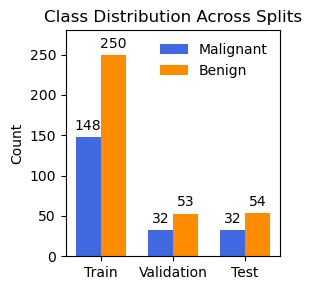

In [118]:
labels = ["Train", "Validation", "Test"]
datasets = [y_train, y_val, y_test]

malignant_counts = []
benign_counts = []

for y_set in datasets:
    classes, counts = np.unique(y_set, return_counts=True)
    malignant_counts.append(counts[0])
    benign_counts.append(counts[1])

x = np.arange(len(labels))

plt.figure(figsize=(3,3))

bars = plt.bar(x - 0.175, malignant_counts, width=0.35, label="Malignant", color='royalblue')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

bars = plt.bar(x + 0.175, benign_counts, width=0.35, label="Benign", color='darkorange')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.xticks(x, labels)
plt.ylim(0,280)
plt.ylabel("Count")
plt.title("Class Distribution Across Splits")
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

The class distribution is consistent across all splits, indicating that stratified sampling preserved the original data proportions.

This is important to ensure that performance metrics are comparable across training, validation, and test sets, and that the model is not evaluated on a distribution different from what it was trained on.

### Evaluation Metrics

To evaluate model performance, we use the following metrics:

- **Accuracy**: overall proportion of correct predictions  
- **Precision**: proportion of predicted positive cases that are correct  
- **Recall**: proportion of actual positive cases that are correctly identified  
- **ROC-AUC**: measures the model’s ability to distinguish between classes across different thresholds  

These metrics provide a balanced view of model performance, especially in classification tasks.

In [120]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "ROC-AUC": roc_auc_score(y, y_prob),
    }